# Phase 5 — Which graph should GraphSAGE use?

## 1 · The question

Original graph, or a role-based one — `psi`, `degree`, `centrality`, `hybrid`?

- Only the graph changes. Encoder, features, K = 10, seeds 42/43/44 stay fixed.
- Each dataset × task gets one answer: keep original, tie, or augment.
- Can that answer be read off the graph's own properties?

One point per dataset, so this is a conjecture rather than a significance test. The three datasets added last were predicted in `docs/paper_log.md` before training.


## 2 · Inputs

Nothing is trained here. Every number is read back from what the study already wrote — scores from `results/scoreboard.csv`, graphs from `input/`, labels from `labels/`, features from `output/feature_cache/`. The work happens in `characterize.py`.

- Each task uses its own metric, so scores are only compared inside one dataset × task cell.
- Weighted F1 sits near its floor on `tolokers` and collapses on `questions` — both are badly imbalanced.
- `EXCLUDE` hides `citeseer_linqs` and `proteins` from this notebook only; nothing is deleted.


In [1]:
"""Setup: repo root, config, the characterization functions. Heavy lifting: experiments/characterize.py."""
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)                     # run everything from the repo root
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from virgo import config as cfg
from experiments.characterize import (STUDY, PREDICTORS, PREDICTORS_PRIMARY, GATES, graph_properties,
                          feature_properties, frozen_inputs, gaps, feature_scores, correlate, candidate_rules)

EXCLUDE = ["citeseer_linqs", "proteins"]            # hidden from THIS notebook only - files, embeddings and scoreboard rows are untouched; empty the list to bring one back
FAMILY = {"citation": "citation", "biological": "molecular", "drug interaction": "molecular",
          "crowdsourcing": "social interaction", "q&a interaction": "social interaction",
          "linguistic": "linguistic"}               # experiments.characterize.STUDY domain -> the four families the panel spans
DATASETS = [ds for ds in STUDY if ds not in EXCLUDE]              # every registered study dataset - the panel grows in experiments.characterize.STUDY, not in the cells below
ORDER = ["original", "psi", "degree", "centrality", "hybrid"]      # control first, then the four augmented graphs
cfg.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

# Saves a figure to results/figures/ and shows it.
def show(fig, name):
    """Save under results/figures/ and display."""
    fig.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""Read everything the study already produced - same six calls as `characterize.py --step all`."""
props = pd.DataFrame([graph_properties(ds) for ds in DATASETS])                  # what each dataset is like
dists = pd.DataFrame([r for ds in DATASETS for r in feature_properties(ds)])     # raw values fed to GraphSAGE
scores = frozen_inputs(DATASETS)                                                 # locked GraphSAGE scores, K=10, 3 seeds
gap = gaps(scores)                                                               # original vs best augmented, per cell
ablation = feature_scores(dists)                                                 # ablation D + each feature's raw spread
ablation = ablation[ablation["dataset"].isin(DATASETS)]                          # feature_scores reads the scoreboard directly, so apply EXCLUDE here too
corr = correlate(props, gap, ablation)                                           # Spearman, both scopes

print(f"{len(props)} datasets | {len(scores)} scores | {len(gap)} dataset x task cells "
      f"| {len(ablation)} ablation rows | {len(dists)} feature distributions")
print(f"excluded from this notebook: {EXCLUDE or 'none'} (still scored in results/scoreboard.csv)")

7 datasets | 60 scores | 12 dataset x task cells | 100 ablation rows | 28 feature distributions
excluded from this notebook: ['citeseer_linqs', 'proteins'] (still scored in results/scoreboard.csv)


## 3 · Which graph wins?

All five variants, one row per dataset × task.

- `winner` — the highest 3-seed mean.
- `verdict` — whether the best role graph beats the original by more than seed noise.
- Heatmap colour is the score relative to the original; the printed numbers are the real scores.


In [3]:
"""Every variant's score, the winner, and the verdict - one row per dataset x task cell."""
piv = scores.pivot_table(index=["task", "dataset"], columns="graph_variant", values="mean")
piv = piv.reindex(columns=ORDER).sort_index()

table = piv.join(gap.set_index(["task", "dataset"])[["metric", "best_variant", "gap_abs", "gap_sigma", "verdict"]])
table.insert(len(ORDER), "winner", piv.idxmax(axis=1))
table.round(4)

original     psi  degree  \
task                               dataset                                  
link prediction (AUC)              cora            0.6130  0.5150  0.5391   
                                   enzymes         0.7000  0.6236  0.5484   
                                   questions       0.4665  0.4923  0.5272   
                                   roman_empire    0.6019  0.5407  0.5092   
                                   tolokers        0.6444  0.7007  0.6936   
link prediction (OGB official)     ogbl_ddi        0.0173  0.0423  0.0331   
node classification (OGB official) ogbn_arxiv      0.3918  0.2466  0.2416   
node classification (weighted F1)  cora            0.4266  0.2351  0.2351   
                                   enzymes         0.5591  0.5480  0.5474   
                                   questions       0.9555  0.9554  0.9554   
                                   roman_empire    0.2561  0.2069  0.2108   
                                   tolokers        0.7345  0.7129  0.7158   

                                                 centrality  hybrid  \
task                               dataset                            
link prediction (AUC)              cora              0.5659  0.5463   
                                   enzymes           0.6563  0.6322   
                                   questions         0.5078  0.5526   
                                   roman_empire      0.6980  0.5408   
                                   tolokers          0.6880  0.6831   
link prediction (OGB official)     ogbl_ddi          0.0519  0.0344   
node classification (OGB official) ogbn_arxiv        0.2658  0.3618   
node classification (weighted F1)  cora              0.2942  0.2918   
                                   enzymes           0.5372  0.5546   
                                   questions         0.9554  0.9555   
                                   roman_empire      0.2093  0.2144   
                                   tolokers          0.7132  0.7265   

                                                     winner        metric  \
task                               dataset                                  
link prediction (AUC)              cora            original           auc   
                                   enzymes         original           auc   
                                   questions         hybrid           auc   
                                   roman_empire  centrality           auc   
                                   tolokers             psi           auc   
link prediction (OGB official)     ogbl_ddi      centrality  test_hits@20   
node classification (OGB official) ogbn_arxiv      original      test_acc   
node classification (weighted F1)  cora            original   weighted_f1   
                                   enzymes         original   weighted_f1   
                                   questions       original   weighted_f1   
                                   roman_empire    original   weighted_f1   
                                   tolokers        original   weighted_f1   

                                                best_variant  gap_abs  \
task                               dataset                              
link prediction (AUC)              cora           centrality  -0.0471   
                                   enzymes        centrality  -0.0437   
                                   questions          hybrid   0.0861   
                                   roman_empire   centrality   0.0961   
                                   tolokers              psi   0.0563   
link prediction (OGB official)     ogbl_ddi       centrality   0.0346   
node classification (OGB official) ogbn_arxiv         hybrid  -0.0300   
node classification (weighted F1)  cora           centrality  -0.1324   
                                   enzymes            hybrid  -0.0045   
                                   questions          hybrid   0.0000   
                    

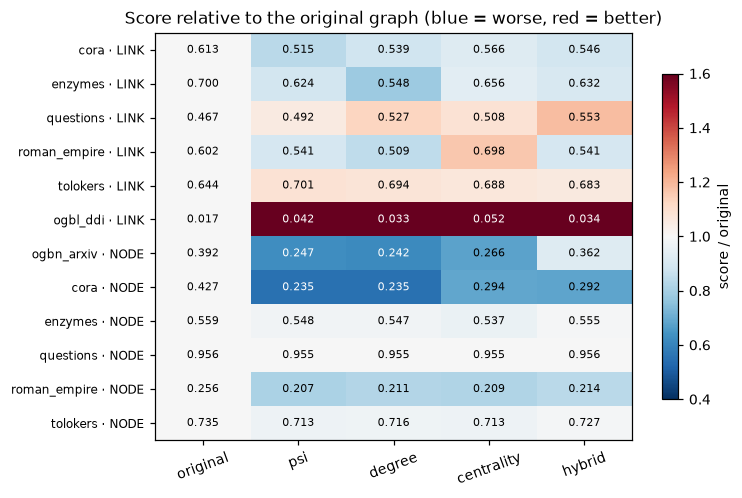

In [4]:
"""The same table as a picture: how far each variant lands from the original graph."""
ratio = piv.div(piv["original"], axis=0)

fig, ax = plt.subplots(figsize=(7, 4.6))
im = ax.imshow(ratio.values, cmap="RdBu_r", vmin=0.4, vmax=1.6, aspect="auto")
ax.grid(False)
ax.set_xticks(range(len(ORDER)), ORDER, rotation=20)
ax.set_yticks(range(len(piv)), [f"{d} · {t.split(' (')[0][:4].upper()}" for t, d in piv.index], fontsize=8)
for i in range(piv.shape[0]):                                   # annotate with the real score, colour carries the ratio
    for j in range(piv.shape[1]):
        dark = abs(ratio.values[i, j] - 1) > 0.35               # keep the label readable on saturated cells
        ax.text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center", fontsize=7.5,
                color="white" if dark else "black")
ax.set_title("Score relative to the original graph (blue = worse, red = better)")
fig.colorbar(im, ax=ax, label="score / original", shrink=0.8)
show(fig, "fig1_variant_vs_original")

## 4 · What is each dataset like?

Grouped into the four families the panel spans. Full table: `results/dataset_characterization.csv`.

- Adjusted homophily is neighbour label agreement above chance — raw homophily can't be compared across datasets with different class counts.
- The molecular graphs are hundreds of small graphs, not one connected graph.


In [5]:
"""The properties that will explain the results; sorted by average degree, the axis the panel spans widest."""
COLS = ["nodes", "avg_degree", "density", "avg_clustering",
        "components", "largest_component_frac", "n_classes", "homophily_adjusted"]
fam = props.assign(family=props["domain"].map(FAMILY))                          # four families: citation, molecular, social interaction, linguistic
fam = fam.sort_values(["family", "avg_degree"]).set_index(["family", "domain", "dataset"])
fam[COLS]

nodes  avg_degree  \
family             domain           dataset                            
citation           citation         cora            2708      3.8981   
                                    ogbn_arxiv    169343     13.6740   
linguistic         linguistic       roman_empire   22662      2.9059   
molecular          biological       enzymes        19474      3.8289   
                   drug interaction ogbl_ddi        4267    500.5442   
social interaction q&a interaction  questions      48921      6.2771   
                   crowdsourcing    tolokers       11758     88.2803   

                                                   density  avg_clustering  \
family             domain           dataset                                  
citation           citation         cora          0.001440          0.2407   
                                    ogbn_arxiv    0.000081          0.2261   
linguistic         linguistic       roman_empire  0.000128          0.3859   
molecular          biological       enzymes       0.000197          0.4024   
                   drug interaction ogbl_ddi      0.117333          0.5143   
social interaction q&a interaction  questions     0.000128          0.0307   
                   crowdsourcing    tolokers      0.007509          0.5329   

                                                  components  \
family             domain           dataset                    
citation           citation         cora                  78   
                                    ogbn_arxiv             1   
linguistic         linguistic       roman_empire           1   
molecular          biological       enzymes              640   
                   drug interaction ogbl_ddi               1   
social interaction q&a interaction  questions              1   
                   crowdsourcing    tolokers               1   

                                                  largest_component_frac  \
family             domain           dataset                                
citation           citation         cora                          0.9177   
                                    ogbn_arxiv                    1.0000   
linguistic         linguistic       roman_empire                  1.0000   
molecular          biological       enzymes                       0.0064   
                   drug interaction ogbl_ddi                      1.0000   
social interaction q&a interaction  questions                     1.0000   
                   crowdsourcing    tolokers                      1.0000   

                                                  n_classes  \
family             domain           dataset                   
citation           citation         cora                  7   
                                    ogbn_arxiv           40   
linguistic         linguistic       roman_empire         18   
molecular          biological       enzymes               3   
                   drug interaction ogbl_ddi              0   
social interaction q&a interaction  questions             2   
                   crowdsourcing    tolokers              2   

                                                  homophily_adjusted  
family             domain           dataset                           
citation           citation         cora                      0.7711  
                                    ogbn_arxiv                0.5877  
linguistic         linguistic       roman_empire             -0.0468  
molecular          biological       enzymes                   0.3613  
                   drug interaction ogbl_ddi                     NaN  
social interaction q&a interaction  questions                 0.0207  
                   crowdsourcing    tolokers                  0.0926

## 5 · Why did a graph win or lose?

The gap — best role graph minus original, as a share of the original — against the property that tracks it.

- Node classification follows adjusted homophily, link prediction follows average degree. Both weakened once the panel grew past five datasets, so treat them as candidates rather than a rule (history in `docs/paper_log.md`).
- `ogbl_ddi` has no labels, so it appears in the degree panel only.
- Second figure checks every property. `degree_assortativity` mirrors homophily, so it isn't extra evidence.


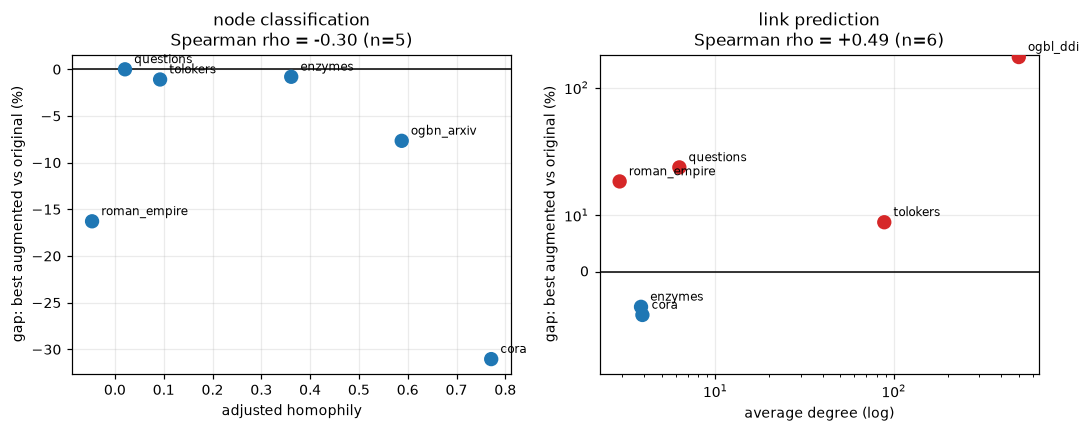

In [6]:
"""The gap against its best predictor, one panel per task - the headline of the study."""
J = gap.merge(props, on="dataset")
PANELS = [("node classification", "homophily_adjusted", "adjusted homophily", False, False),
          ("link prediction", "avg_degree", "average degree (log)", True, True)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (task, prop, label, logx, symlog) in zip(axes, PANELS):
    g = J[J["task_family"] == task].dropna(subset=[prop])
    r = corr[(corr["task_family"] == task) & (corr["predictor"] == prop) & (corr["target"] == "gap_rel")].iloc[0]
    ax.axhline(0, color="k", lw=1)
    ax.scatter(g[prop], 100 * g["gap_rel"], s=70, c=["tab:red" if v > 0 else "tab:blue" for v in g["gap_rel"]], zorder=3)
    for _, row in g.iterrows():
        ax.annotate(row["dataset"], (row[prop], 100 * row["gap_rel"]), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)
    if logx:
        ax.set_xscale("log")
    if symlog:
        ax.set_yscale("symlog", linthresh=20)      # ddi's +200% is a floor effect (original = 0.017), so compress it
    ax.set(xlabel=label, ylabel="gap: best augmented vs original (%)",
           title=f"{task}\nSpearman rho = {r.spearman_rho:+.2f} (n={r.n})")
show(fig, "fig2_gap_vs_predictor")

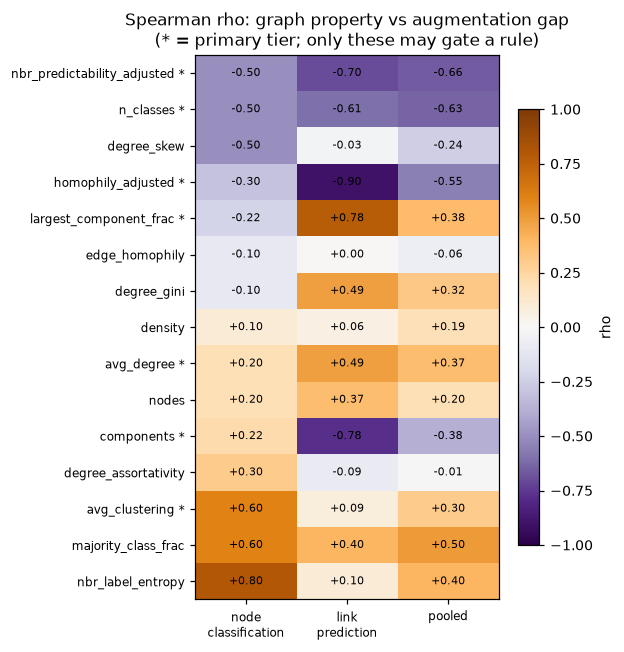

In [7]:
"""Every property against the gap, both tasks - the evidence behind the two panels above."""
H = (corr[corr["scope"].str.startswith("graph") & (corr["target"] == "gap_rel")]
     .pivot(index="predictor", columns="task_family", values="spearman_rho")
     .reindex(PREDICTORS)[["node classification", "link prediction", "pooled"]])
H = H.sort_values("node classification")

fig, ax = plt.subplots(figsize=(5.6, 6.0))
im = ax.imshow(H.values, cmap="PuOr_r", vmin=-1, vmax=1, aspect="auto")
ax.grid(False)
ax.set_xticks(range(H.shape[1]), [c.replace(" ", "\n") for c in H.columns], fontsize=8)
ax.set_yticks(range(len(H)), [f"{p} *" if p in PREDICTORS_PRIMARY else p for p in H.index], fontsize=8)  # * = primary tier
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, f"{H.values[i, j]:+.2f}", ha="center", va="center", fontsize=7.5)
ax.set_title("Spearman rho: graph property vs augmentation gap\n(* = primary tier; only these may gate a rule)")
fig.colorbar(im, ax=ax, label="rho", shrink=0.8)
show(fig, "fig3_property_correlations")

## 6 · Which node feature helps?

Ablation D turns the four structural features on one at a time, on the `psi` graph.

- Bars show each feature's lift over a random-feature control — the same message passing with the structural signal removed.
- `clustering` carries the molecular graphs, `centrality` the citation ones.
- Second figure: how spread out a feature's raw values are says nothing about whether it helps. Usefulness comes from the ablation score, not from a "too few distinct values" rule of thumb.


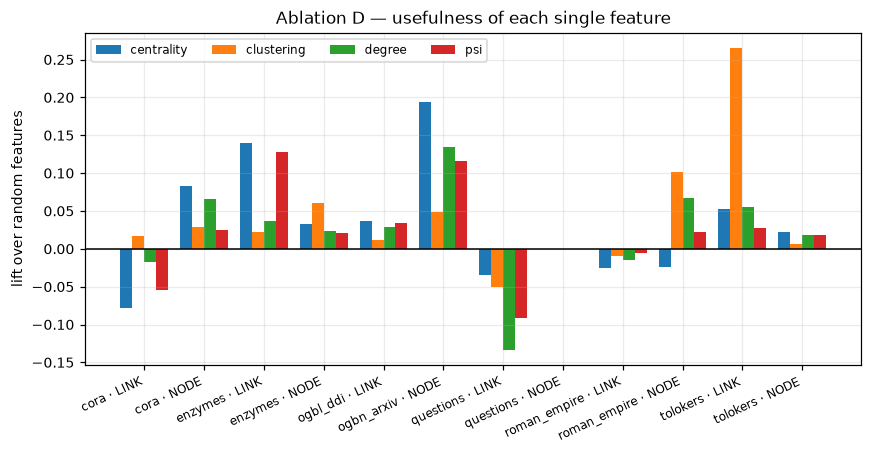

In [8]:
"""Ablation D lift over the random-feature control, per dataset x task."""
S = ablation[ablation["feature"].notna()].copy()
S["cell"] = S["dataset"] + " · " + S["task_family"].str.split(" ").str[0].str.upper()
L = S.pivot(index="cell", columns="arm", values="lift_vs_random").sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(L))
for i, arm in enumerate(L.columns):
    ax.bar(x + (i - 1.5) * 0.2, L[arm], width=0.2, label=arm)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x, L.index, rotation=25, ha="right", fontsize=8)
ax.set(ylabel="lift over random features", title="Ablation D — usefulness of each single feature")
ax.legend(fontsize=8, ncol=4, loc="upper left")
show(fig, "fig4_feature_lift")

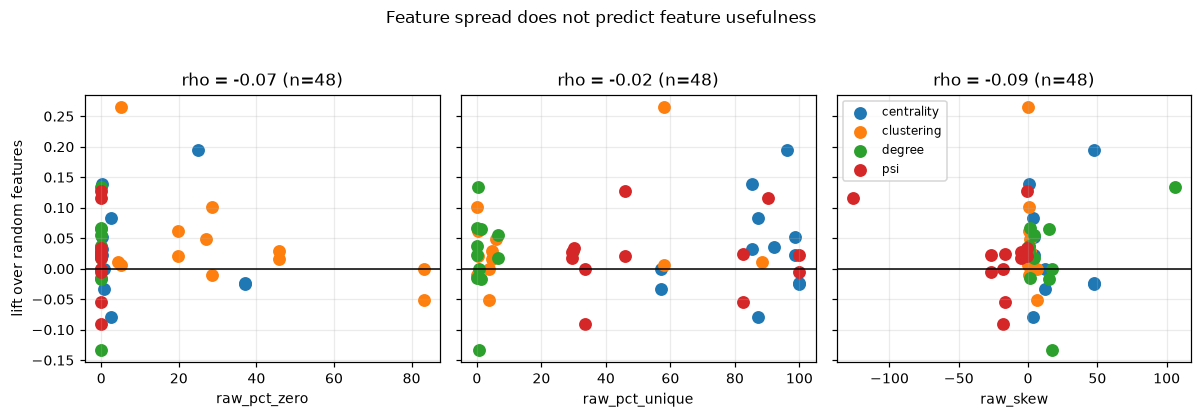

In [9]:
"""Raw distribution statistics against measured usefulness - the test the degenerate flag would have to pass."""
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, p in zip(axes, ["raw_pct_zero", "raw_pct_unique", "raw_skew"]):
    r = corr[(corr["scope"].str.startswith("feature")) & (corr["task_family"] == "pooled")
             & (corr["predictor"] == p)].iloc[0]
    for arm, g in S.groupby("arm"):
        ax.scatter(g[p], g["lift_vs_random"], s=55, label=arm)
    ax.axhline(0, color="k", lw=1)
    ax.set(xlabel=p, title=f"rho = {r.spearman_rho:+.2f} (n={r.n})")
axes[0].set_ylabel("lift over random features")
axes[-1].legend(fontsize=8)
fig.suptitle("Feature spread does not predict feature usefulness", y=1.04)
show(fig, "fig5_spread_vs_usefulness")

## 7 · Final recommendation

**7a — which graph to use.** A tie means the two graphs are indistinguishable, so the role graph is still named there; only a clear _keep original_ falls back to the original.

- `best_minus_original` — best role graph minus original, in that cell's own metric. Negative means the original is ahead.
- `explanation` — the same gap measured in seed noise, plus where the original ranks out of five.

**7b — which feature carries the signal.** `psi` graph only, so it explains a verdict and never decides one.

- `strongest_feature` — the best single-feature arm, with its lift over random features in brackets.
- `vs_random_features` — whether that lift clears seed noise, on a stricter band than 7a's verdict. `metric constant` means the metric never moved at all (`questions` node classification).


In [10]:
"""7a - the when-to-augment answer per cell: properties, verdict, gap, explanation."""
rec = gap.merge(props[["dataset", "avg_degree", "homophily_adjusted"]], on="dataset", how="left")
# On a tie the two graphs are statistically indistinguishable, so the augmented variant is named too - only a clear
# "keep original" verdict falls back to the original graph.
rec["recommended_graph"] = np.where(rec["verdict"] == "keep original", "original", rec["best_variant"])
rec["explanation"] = [f"{r.gap_abs:+.4f} {r.metric} = {r.gap_sigma:+.1f} sigma | original ranks {r.original_rank}/5"
                      for r in rec.itertuples()]
rec = rec.rename(columns={"gap_abs": "best_minus_original"})       # gap_abs was opaque: it is best augmented - original, in that cell's own metric

display(rec[["dataset", "task_family", "verdict", "recommended_graph", "best_variant",
             "avg_degree", "homophily_adjusted", "best_minus_original", "explanation"]].round(4))

n = rec["verdict"].value_counts()                                  # display() first so this tally prints BELOW the table
print(" | ".join(f"{v}: {n.get(v, 0)}" for v in ["keep original", "augment", "tie"]))

,dataset,task_family,verdict,recommended_graph,best_variant,avg_degree,homophily_adjusted,best_minus_original,explanation
0,cora,link prediction,keep original,original,centrality,3.8981,0.7711,-0.0471,-0.0471 auc = -11.5 sigma | original ranks 1/5
1,enzymes,link prediction,keep original,original,centrality,3.8289,0.3613,-0.0437,-0.0437 auc = -6.1 sigma | original ranks 1/5
2,ogbl_ddi,link prediction,augment,centrality,centrality,500.5442,NaN,0.0346,+0.0346 test_hits@20 = +2.7 sigma | original r...
3,questions,link prediction,augment,hybrid,hybrid,6.2771,0.0207,0.0861,+0.0861 auc = +4.6 sigma | original ranks 5/5
4,roman_empire,link prediction,augment,centrality,centrality,2.9059,-0.0468,0.0961,+0.0961 auc = +7.3 sigma | original ranks 2/5
5,tolokers,link prediction,augment,psi,psi,88.2803,0.0926,0.0563,+0.0563 auc = +4.2 sigma | original ranks 5/5
6,cora,node classification,keep original,original,centrality,3.8981,0.7711,-0.1324,-0.1324 weighted_f1 = -8.6 sigma | original ra...
7,enzymes,node classification,tie,hybrid,hybrid,3.8289,0.3613,-0.0045,-0.0045 weighted_f1 = -0.7 sigma | original ra...
8,ogbn_arxiv,node classification,keep original,original,hybrid,13.6740,0.5877,-0.0300,-0.0300 test_acc = -6.2 sigma | original ranks...
9,questions,node classification,keep original,original,hybrid,6.2771,0.0207,0.0000,+0.0000 weighted_f1 = +nan sigma | original ra...


keep original: 7 | augment: 4 | tie: 1


In [11]:
"""7b - strongest single structural feature on the psi graph, its lift over random features, and whether that lift is real."""
best = S.loc[S.groupby(["dataset", "task_family"])["mean"].idxmax()]        # strongest single feature in that cell
feat = gap[["dataset", "task_family"]].merge(
    best[["dataset", "task_family", "arm", "lift_vs_random", "lift_sigma", "vs_random_features"]],
    on=["dataset", "task_family"], how="left")
feat["vs_random_features"] = feat["vs_random_features"].fillna("not measured")   # no ablation arms on disk for that cell at all
# Lift printed inline so the feature and its margin read as one fact; "-" wherever no margin is measurable.
feat["strongest_feature"] = [f"{a} ({l:+.3f})" if st not in ("metric constant", "not measured") else "-"
                             for a, l, st in zip(feat["arm"], feat["lift_vs_random"], feat["vs_random_features"])]
feat = feat.rename(columns={"lift_sigma": "feature_lift_sigma"})

display(feat[["dataset", "task_family", "strongest_feature",
              "feature_lift_sigma", "vs_random_features"]].round(4))

n = feat["vs_random_features"].value_counts()                      # display() first so this tally prints BELOW the table
print(" | ".join(f"{v}: {n.get(v, 0)}" for v in
                 ["beats random", "tied with random", "worse than random", "not measured", "metric constant"]))

,dataset,task_family,strongest_feature,feature_lift_sigma,vs_random_features
0,cora,link prediction,clustering (+0.016),1.76,tied with random
1,enzymes,link prediction,centrality (+0.140),31.49,beats random
2,ogbl_ddi,link prediction,centrality (+0.036),5.35,beats random
3,questions,link prediction,centrality (-0.034),-2.04,worse than random
4,roman_empire,link prediction,psi (-0.006),-1.74,tied with random
5,tolokers,link prediction,clustering (+0.265),21.01,beats random
6,cora,node classification,centrality (+0.083),15.59,beats random
7,enzymes,node classification,clustering (+0.061),16.52,beats random
8,ogbn_arxiv,node classification,centrality (+0.194),305.47,beats random
9,questions,node classification,-,NaN,metric constant


beats random: 8 | tied with random: 2 | worse than random: 1 | not measured: 0 | metric constant: 1


## 8 · Candidate rules

Each property turned into a decision: one threshold, one side that says _augment_.

- Passes if |rho| ≥ 0.7, direction survives dropping any one dataset, and ≤ 1 cell is misclassified.
- `components` and `largest_component_frac` rank identically (rho = −1.000), so they count as one finding.

**Two rules kept, both link prediction:** adjusted homophily < 0.227, and largest-component fraction > 0.9588.
`nbr_predictability_adjusted` was screened and dropped. Node classification gives no rule — nothing augments, so there is no line to draw.

Candidates, not proof: each was read off the datasets it scores on. Full reasoning in `docs/paper_log.md`.


In [12]:
"""Screen every primary property as a binary keep-vs-augment rule, both gap definitions."""
cand = candidate_rules(props, gap)

display(cand[["task_family", "target", "predictor", "predictor_family", "canonical", "n_cells", "n_augment",
              "distinct_augment", "spearman_rho", "p_bonferroni", "lodo_min_abs_rho", "lodo_sign_stable",
              "threshold", "augment_side", "n_exceptions", "credible"]].round(4))

keep = cand[cand["credible"] & cand["canonical"]]                  # one row per FINDING: collinear predictors collapse to one
print("CREDIBLE FINDINGS: " + ("; ".join(dict.fromkeys(keep["rule"])) if len(keep) else "none clear the gates"))
thin = keep[keep["distinct_augment"] <= 1]["predictor"].unique()   # every augmenting graph at one value = group label, not a trend
if len(thin):
    print("WEAK - two-group split, not a graded trend: " + ", ".join(thin))
for name, sub in cand.groupby("task_family"):                      # a family with no augment cell has nothing to separate
    if sub["n_augment"].max() == 0:
        print(f"{name}: no augment cell exists -> only the boundary 'never augment' is reportable, not a rule")

,task_family,target,predictor,predictor_family,canonical,n_cells,n_augment,distinct_augment,spearman_rho,p_bonferroni,lodo_min_abs_rho,lodo_sign_stable,threshold,augment_side,n_exceptions,credible
0,link prediction,gap_fixed_rel,avg_clustering,avg_clustering,True,6,4,4,0.2000,1.0000,0.1000,False,0.3133,high,2,False
1,link prediction,gap_fixed_rel,avg_degree,avg_degree,True,6,4,4,0.3143,1.0000,0.2000,False,5.0876,high,1,False
2,link prediction,gap_fixed_rel,components,fragmentation,False,6,4,1,-0.7775,0.4809,0.7071,True,39.5000,low,0,True
3,link prediction,gap_fixed_rel,homophily_adjusted,homophily_adjusted,True,5,3,3,-1.0000,0.1169,1.0000,True,0.2270,low,0,True
4,link prediction,gap_fixed_rel,largest_component_frac,fragmentation,True,6,4,1,0.7775,0.4809,0.7071,True,0.9588,high,0,True
5,link prediction,gap_fixed_rel,n_classes,n_classes,True,6,4,3,-0.4058,1.0000,0.0513,False,2.5000,low,1,False
6,link prediction,gap_fixed_rel,nbr_predictability_adjusted,nbr_predictability_adjusted,True,5,3,3,-0.6000,1.0000,0.2000,True,0.4084,low,0,False
7,link prediction,gap_rel,avg_clustering,avg_clustering,True,6,4,4,0.0857,1.0000,0.0000,False,0.3133,high,2,False
8,link prediction,gap_rel,avg_degree,avg_degree,True,6,4,4,0.4857,1.0000,0.1000,True,5.0876,high,1,False
9,link prediction,gap_rel,components,fragmentation,False,6,4,1,-0.7775,0.4809,0.7071,True,39.5000,low,0,True


CREDIBLE FINDINGS: link prediction: augment when homophily_adjusted is low (< 0.227); link prediction: augment when largest_component_frac is high (> 0.9588); link prediction: augment when nbr_predictability_adjusted is low (< 0.4084)
WEAK - two-group split, not a graded trend: largest_component_frac
node classification: no augment cell exists -> only the boundary 'never augment' is reportable, not a rule


### 8b · The two rules, dataset by dataset

Link prediction only — the rules do not apply to node classification, where nothing augments.

- **Adjusted homophily** — do neighbours share a label, above chance? Lower → augmentation helps more. Rule: augment when **< 0.227**.
- **Largest-component fraction** — share of nodes in one connected piece. Higher → augmentation helps more. Rule: augment when **> 0.9588**.
- **Observed gap** — best augmented minus original, as % of original. Positive = augmentation won.
- **Confidence** — how far the gap sits beyond 3-seed noise, in words.


In [13]:
"""8b - what each rule predicts per dataset, what actually happened, and whether the rule was right."""
RULES = [("homophily_adjusted", "<", 0.227), ("largest_component_frac", ">", 0.9588)]
WORDS = {"augment": "Augment", "keep original": "Keep", "tie": "Tie"}

# One rule on one dataset -> its prediction, or n/a when the property needs labels the graph does not have.
def predicts(v, op, t):
    """Augment / Keep for one threshold rule; n/a when the value is missing."""
    return "n/a" if v != v else ("Augment" if (v < t if op == "<" else v > t) else "Keep")

# How far the gap sits beyond the pooled 3-seed noise, said in words instead of sigma.
def confidence(s):
    """within noise / clear / strong / very strong."""
    return "within noise" if abs(s) < 1 else ("clear" if abs(s) < 3 else ("strong" if abs(s) < 5 else "very strong"))

rows = []
for r in gap[(gap["task_family"] == "link prediction") & gap["usable"]].merge(props, on="dataset").itertuples():
    said = [predicts(getattr(r, c), op, t) for c, op, t in RULES]
    real, live = WORDS[r.verdict], [s for s in said if s != "n/a"]
    if len(set(live)) > 1:
        note = "rules DISAGREE -> the case worth testing"
    else:
        note = ("correct" if live[0] == real else "WRONG") + (" (connectivity only)" if len(live) == 1 else " (both rules)")
    rows.append({"Dataset": r.dataset,
                 "Adj. homophily": r.homophily_adjusted, "Homophily rule says": said[0],
                 "Largest-comp fraction": r.largest_component_frac, "Connectivity rule says": said[1],
                 "Observed gap": f"{100 * r.gap_rel:+.1f}%", "Confidence": confidence(r.gap_sigma),
                 "Actual verdict": real, "Interpretation": note})

display(pd.DataFrame(rows).sort_values("Adj. homophily").reset_index(drop=True).round(4))
print("Rules apply to link prediction only. Node classification never augments, so no rule exists to apply there.")

,Dataset,Adj. homophily,Homophily rule says,Largest-comp fraction,Connectivity rule says,Observed gap,Confidence,Actual verdict,Interpretation
0,roman_empire,-0.0468,Augment,1.0000,Augment,+16.0%,very strong,Augment,correct (both rules)
1,questions,0.0207,Augment,1.0000,Augment,+18.5%,strong,Augment,correct (both rules)
2,tolokers,0.0926,Augment,1.0000,Augment,+8.7%,strong,Augment,correct (both rules)
3,enzymes,0.3613,Keep,0.0064,Keep,-6.2%,very strong,Keep,correct (both rules)
4,cora,0.7711,Keep,0.9177,Keep,-7.7%,very strong,Keep,correct (both rules)
5,ogbl_ddi,NaN,n/a,1.0000,Augment,+200.0%,clear,Augment,correct (connectivity only)


Rules apply to link prediction only. Node classification never augments, so no rule exists to apply there.
